In [1]:
using NCDatasets
using Plots
using Statistics

In [3]:
ds = Dataset(joinpath("requested_files",
                      "AQUA_MODIS.20100617.L3m.DAY.CHL.x_chlor_a.nc"))

Dataset: requested_files\AQUA_MODIS.20100617.L3m.DAY.CHL.x_chlor_a.nc
Group: /

Dimensions
   lat = 29
   lon = 48
   rgb = 3
   eightbitcolor = 256

Variables
  chlor_a   (48 × 29)
    Datatype:    Union{Missing, Float32} (Float32)
    Dimensions:  lon × lat
    Attributes:
     long_name            = Chlorophyll Concentration, OCI Algorithm
     units                = mg m^-3
     standard_name        = mass_concentration_of_chlorophyll_in_sea_water
     _FillValue           = -32767.0
     valid_min            = 0.001
     valid_max            = 100.0
     reference            = Hu, C., Feng, L., Lee, Z., Franz, B. A., Bailey, S. W., Werdell, P. J. and Proctor, C. W. (2019). Improving Satellite Global Chlorophyll a Data Products Through Algorithm Renement and Data Recovery. Journal of Geophysical Research: Oceans, 124(3), 1524--1543. and O'Reilly, J. E. and Werdell, P. J. (2019). Chlorophyll algorithms for ocean color sensors - OC4, OC5 and OC6.Remote Sensing of Environment, 229, 32

In [4]:
chl = ds["chlor_a"][:]
lat = ds["lat"][:]
lon = ds["lon"][:]

48-element Vector{Union{Missing, Float32}}:
 -84.17916
 -84.1375
 -84.09583
 -84.05416
 -84.0125
 -83.97083
 -83.92916
 -83.8875
 -83.84583
 -83.80416
 -83.7625
 -83.72083
 -83.67916
   ⋮
 -82.67916
 -82.6375
 -82.59583
 -82.55416
 -82.5125
 -82.47083
 -82.42916
 -82.3875
 -82.34583
 -82.30416
 -82.2625
 -82.22083

In [5]:
close(ds)

closed Dataset

In [6]:
size(chl)
heatmap(chl)

MethodError: MethodError: no method matching size(::Nothing)
The function `size` exists, but no method is defined for this combination of argument types.

[0mClosest candidates are:
[0m  size([91m::Compiler.TwoPhaseVectorView[39m)
[0m[90m   @[39m [90mBase[39m [90mC:\Users\jlhar\.julia\juliaup\julia-1.12.6+0.x64.w64.mingw32\share\julia\Compiler\src\[39m[90m[4minferencestate.jl:81[24m[39m
[0m  size([91m::DiskArrays.RegularChunks[39m)
[0m[90m   @[39m [33mDiskArrays[39m [90mC:\Users\jlhar\.julia\packages\DiskArrays\HhkM2\src\[39m[90m[4mchunks.jl:82[24m[39m
[0m  size([91m::DiskArrays.RegularChunks[39m, [91m::Any[39m)
[0m[90m   @[39m [33mDiskArrays[39m [90mC:\Users\jlhar\.julia\packages\DiskArrays\HhkM2\src\[39m[90m[4mchunks.jl:81[24m[39m
[0m  ...


In [9]:
using NCDatasets
using Plots
using Statistics

ds = Dataset(joinpath(
    "requested_files",
    "AQUA_MODIS.20100617.L3m.DAY.CHL.x_chlor_a.nc"
))

chl = ds["chlor_a"][:, :]
lat = ds["lat"][:]
lon = ds["lon"][:]

println("Chlorophyll size: ", size(chl))
println("Latitude points: ", length(lat))
println("Longitude points: ", length(lon))

heatmap(
    lon,
    lat,
    chl',
    xlabel = "Longitude",
    ylabel = "Latitude",
    title = "Lake Erie Chlorophyll-a (2010-06-17)",
    colorbar_title = "mg/m³"
)

close(ds)

Chlorophyll size: (48, 29)
Latitude points: 29
Longitude points: 48


closed Dataset

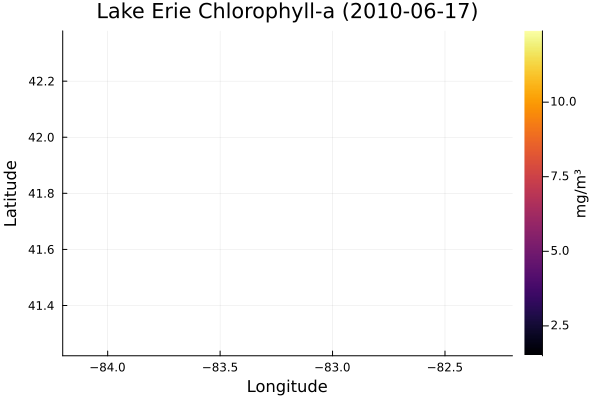

print device already activated
y points not sorted in ascending order
y points not sorted in ascending order
y points not sorted in ascending order


In [10]:
using Plots

p = heatmap(
    lon,
    lat,
    chl',
    xlabel="Longitude",
    ylabel="Latitude",
    title="Lake Erie Chlorophyll-a (2010-06-17)",
    colorbar_title="mg/m³"
)

display(p)

In [11]:
using Statistics

println("Missing: ", count(ismissing, chl))
println("Total: ", length(chl))

vals = collect(skipmissing(chl))

println("Valid values: ", length(vals))

if !isempty(vals)
    println("Min: ", minimum(vals))
    println("Max: ", maximum(vals))
    println("Mean: ", mean(vals))
end

Missing: 1014
Total: 1392
Valid values: 378
Min: 1.497011
Max: 12.389787
Mean: 3.6928756


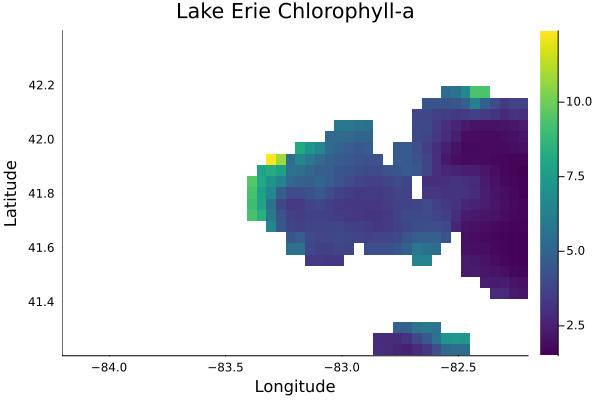

In [12]:
chl_plot = Float64.(coalesce.(chl, NaN))

heatmap(
    lon,
    reverse(lat),
    chl_plot',
    xlabel="Longitude",
    ylabel="Latitude",
    title="Lake Erie Chlorophyll-a",
    color=:viridis
)